In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

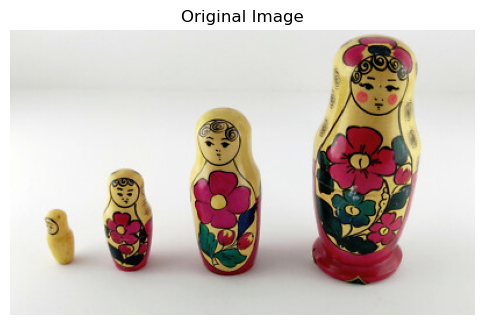

In [3]:
img = cv2.imread("doll.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

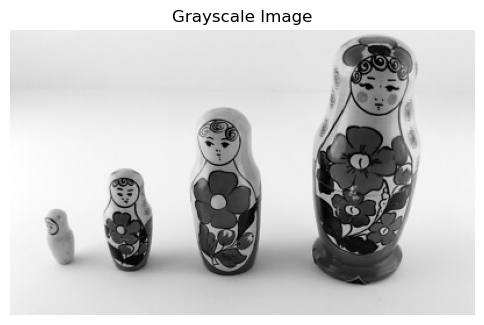

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

Gaussian Blur

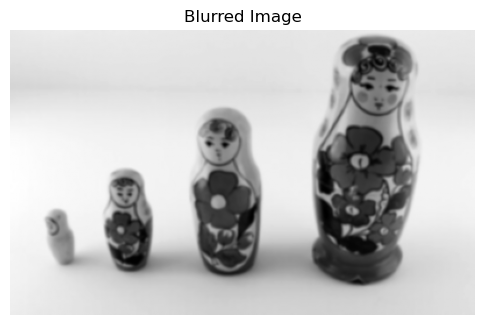

In [5]:
blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.figure(figsize=(6,6))
plt.imshow(blur, cmap="gray")
plt.title("Blurred Image")
plt.axis("off")
plt.show()

Simple Binary Thresholding

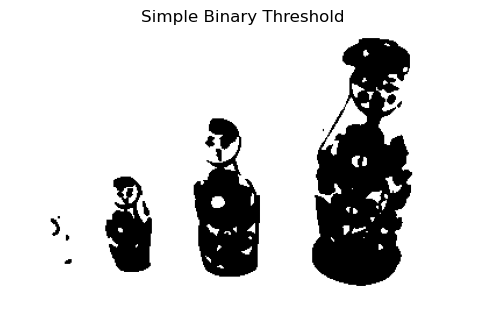

In [22]:
ret1, th_binary = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(6,6))
plt.imshow(th_binary, cmap="gray")
plt.title("Simple Binary Threshold")
plt.axis("off")
plt.show()

Simple Binary Inverse Thresholding

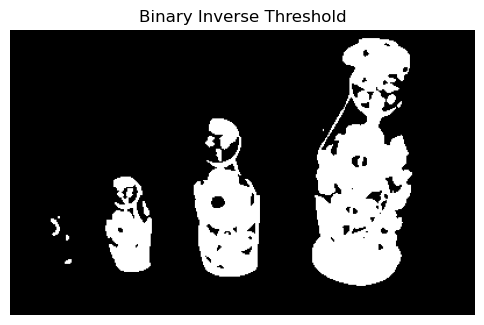

In [23]:
ret2, th_binary_inv = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(6,6))
plt.imshow(th_binary_inv, cmap="gray")
plt.title("Binary Inverse Threshold")
plt.axis("off")
plt.show()

Adaptive Mean Thresholding

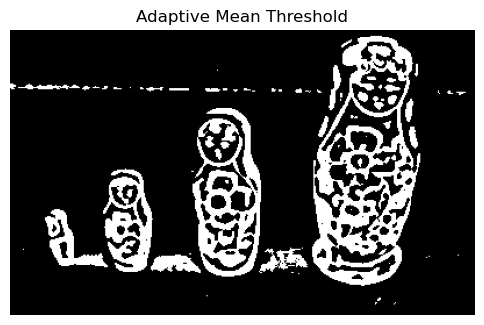

In [24]:
th_adaptive_mean = cv2.adaptiveThreshold(
    blur, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY_INV,
    11, 2
)

plt.figure(figsize=(6,6))
plt.imshow(th_adaptive_mean, cmap="gray")
plt.title("Adaptive Mean Threshold")
plt.axis("off")
plt.show()

Adaptive Gaussian Thresholding

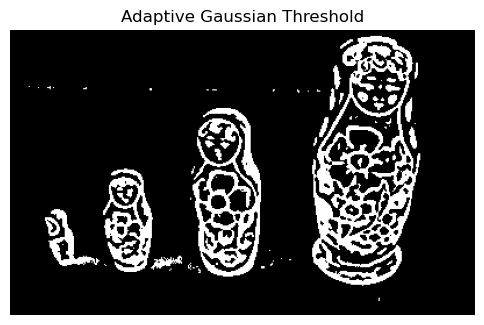

In [25]:
th_adaptive_gaussian = cv2.adaptiveThreshold(
    blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11, 2
)

plt.figure(figsize=(6,6))
plt.imshow(th_adaptive_gaussian, cmap="gray")
plt.title("Adaptive Gaussian Threshold")
plt.axis("off")
plt.show()

Otsu Thresholding

Otsu Threshold Value: 153.0


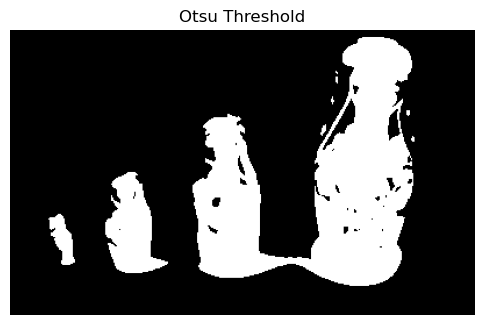

In [26]:
ret3, th_otsu = cv2.threshold(
    blur, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print("Otsu Threshold Value:", ret3)

plt.figure(figsize=(6,6))
plt.imshow(th_otsu, cmap="gray")
plt.title("Otsu Threshold")
plt.axis("off")
plt.show()

Compare

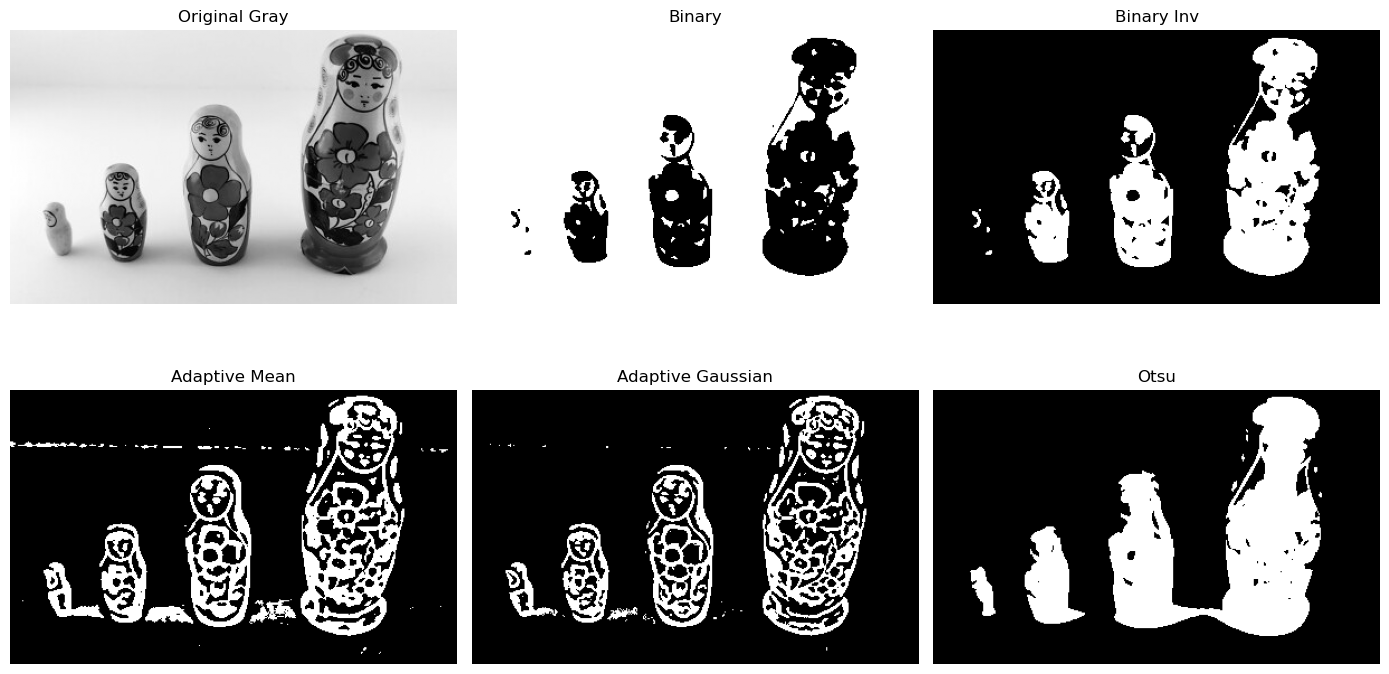

In [27]:
titles = [
    "Original Gray",
    "Binary",
    "Binary Inv",
    "Adaptive Mean",
    "Adaptive Gaussian",
    "Otsu"
]

images = [
    gray,
    th_binary,
    th_binary_inv,
    th_adaptive_mean,
    th_adaptive_gaussian,
    th_otsu
]

plt.figure(figsize=(14,8))

for i in range(6):
    plt.subplot(2, 3, i+1)
    if i == 0:
        plt.imshow(images[i], cmap="gray")
    else:
        plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Extracting Image

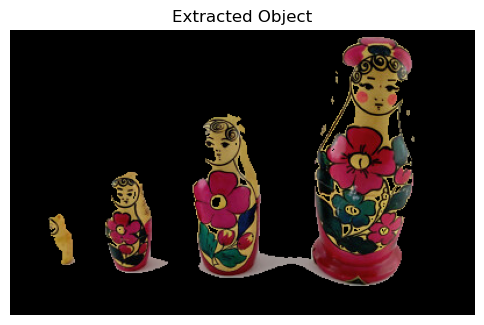

In [28]:
mask = th_otsu

result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

plt.figure(figsize=(6,6))
plt.imshow(result)
plt.title("Extracted Object")
plt.axis("off")
plt.show()

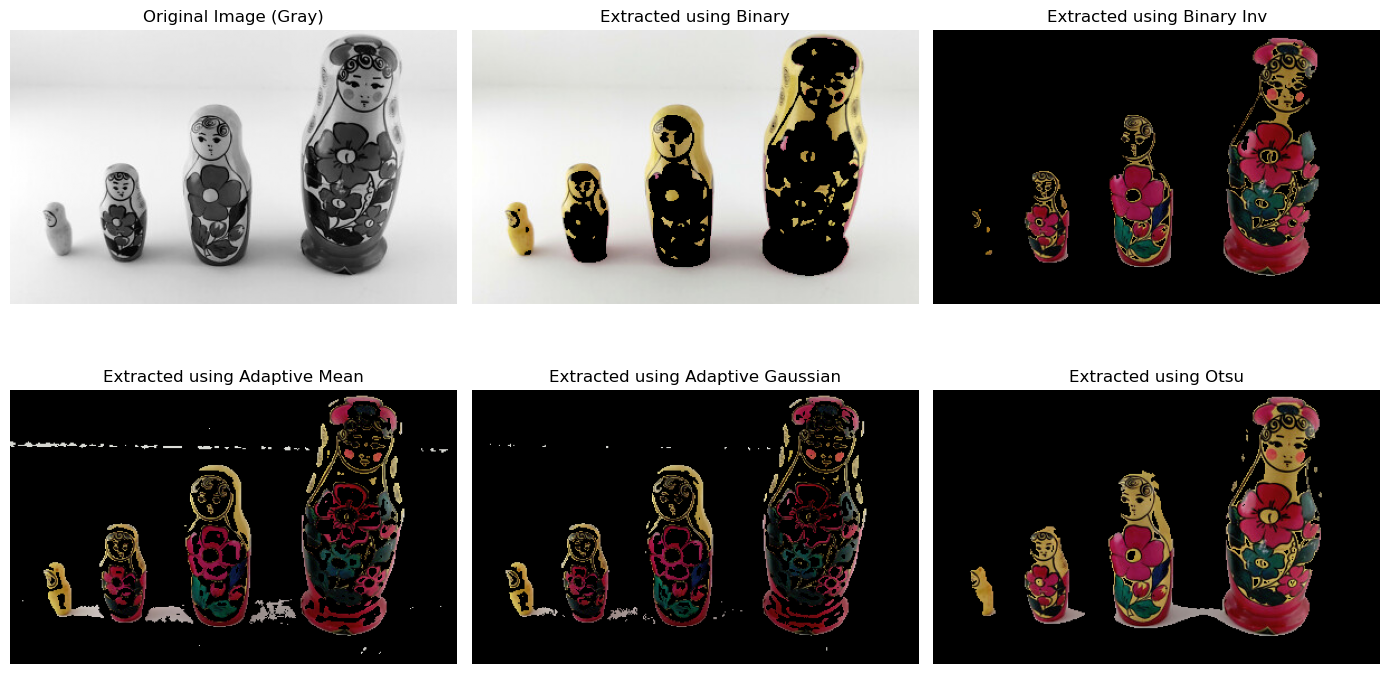

In [29]:
titles = [
    "Original Image (Gray)",
    "Extracted using Binary",
    "Extracted using Binary Inv",
    "Extracted using Adaptive Mean",
    "Extracted using Adaptive Gaussian",
    "Extracted using Otsu"
]

images = [
    gray,
    th_binary,
    th_binary_inv,
    th_adaptive_mean,
    th_adaptive_gaussian,
    th_otsu
]

plt.figure(figsize=(14,8))

for i in range(6):
    
    plt.subplot(2, 3, i+1)
    if i == 0:
        plt.imshow(images[i], cmap="gray")
    else:
        mask = images[i]
        result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
        plt.imshow(result)
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Comparison Result

From the comparison above:

- Simple Binary loses internal details
- Binary Inverse performs better, but is still incomplete
- Adaptive methods introduce noise in the background
- Otsu thresholding provides the cleanest segmentation

Therefore, Otsu thresholding is selected as the final method.

Among all thresholding methods, Otsu thresholding produced the cleanest object extraction with less background noise, so it was selected as the final method.